
# SOFR Cap Forward Volatility

This notebook strips forward volatility from SOFR cap quotes and tests whether
the cap-implied forward-vol curve behaves like an expectations curve or a
risk-premium curve.

The presentation version focuses on the research argument and keeps the curve
construction in `src/sofr_forward_vol.py` so the implementation can be audited.



## Executive takeaways

- The stripping engine reproduces the validation curve to tight tolerances on
  the 2025-06-30 benchmark date.
- The forward-vol curve is not an unbiased predictor of future short-tenor
  implied vol.  Slopes are far from one and inference is fragile once overlapping
  forecast horizons are handled with HAC errors and effective sample counts.
- The positive premium is economically intuitive during the 2022 hiking cycle,
  but the longer-tenor Sharpe-like statistics are mostly an overlapping-sample
  illusion.  A recruiter should see this as a disciplined research conclusion,
  not a forced trading claim.


In [1]:

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from sofr_forward_vol import (
    build_cap_curve,
    build_forward_vol_panel,
    forward_realized_sofr_vol,
    load_data,
    policy_regime,
    predictive_regressions,
    premium_summary,
    term_premium_panel,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## 1. Data and public-repo contract

The raw workbooks are local inputs and are ignored by git.  The notebook reports
only aggregate diagnostics and figures.


In [2]:

data = load_data(PROJECT_ROOT)

overview = pd.DataFrame(
    {
        "rows": [
            len(data.cap_normal_vol_bp),
            len(data.sofr_swaps),
            len(data.sofr_daily),
        ],
        "start": [
            data.cap_normal_vol_bp.index.min().date(),
            data.sofr_swaps.index.min().date(),
            data.sofr_daily.index.min().date(),
        ],
        "end": [
            data.cap_normal_vol_bp.index.max().date(),
            data.sofr_swaps.index.max().date(),
            data.sofr_daily.index.max().date(),
        ],
        "columns_or_series": [
            len(data.cap_normal_vol_bp.columns),
            len(data.sofr_swaps.columns),
            1,
        ],
    },
    index=["cap normal vol quotes", "SOFR swap quotes", "daily SOFR"],
)
display(overview)


,rows,start,end,columns_or_series
cap normal vol quotes,989,2022-03-17,2025-12-31,10
SOFR swap quotes,1033,2022-01-03,2025-12-31,21
daily SOFR,1935,2018-04-03,2025-12-31,1



## 2. Curve construction and validation

The quoted cap vols are normal vols in basis points.  To replicate the course
validation workbook, the engine converts them into Black-equivalent flat vols
using the ATM approximation `normal_vol / forward_rate`, then strips marginal
caplet vols by repricing each cap.  Time-series tests are converted back into
normal-vol units.


,max,mean
discount_error,0.0000,0.0000
forward_rate_error,0.0001,0.0000
flat_black_vol_error,0.0023,0.0002
forward_black_vol_error,0.0023,0.0004


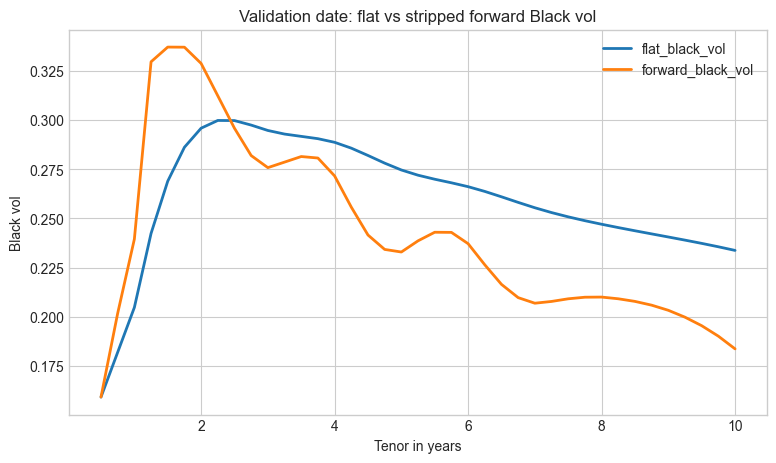

In [3]:

validation_date = "2025-06-30"
curve = build_cap_curve(validation_date, data, interpolation="cubic")

comparison = pd.DataFrame(
    {
        "discount_error": curve["discount"] - data.validation_curve["discounts"],
        "forward_rate_error": curve["forward_rate"] - data.validation_curve["forwards"],
        "flat_black_vol_error": curve["flat_black_vol"] - data.validation_curve["flat vols"],
        "forward_black_vol_error": curve["forward_black_vol"] - data.validation_curve["fwd vols"],
    }
)
validation_summary = comparison.abs().agg(["max", "mean"]).T
display(validation_summary)

fig, ax = plt.subplots(figsize=(9, 5))
curve[["flat_black_vol", "forward_black_vol"]].plot(ax=ax, linewidth=2)
ax.set_title("Validation date: flat vs stripped forward Black vol")
ax.set_xlabel("Tenor in years")
ax.set_ylabel("Black vol")
plt.show()



## 3. Forward-vol panel and surface factor structure

The panel is sampled weekly to avoid pretending that daily quote changes provide
independent observations.  I use normal-vol units for time-series inference
because the raw cap market quotes are normal vols.


,mean_bp,std_bp,min_bp,max_bp
tenor,,,,
0.5000,72.8762,38.0742,15.4408,255.2123
1.0000,109.0491,37.5775,55.7294,242.6308
1.5000,134.5435,36.4561,68.4460,221.4798
2.0000,136.1460,32.8377,73.4188,198.3910
3.0000,128.3665,30.6865,74.4682,195.8787
5.0000,103.8997,18.2418,69.8828,178.1636


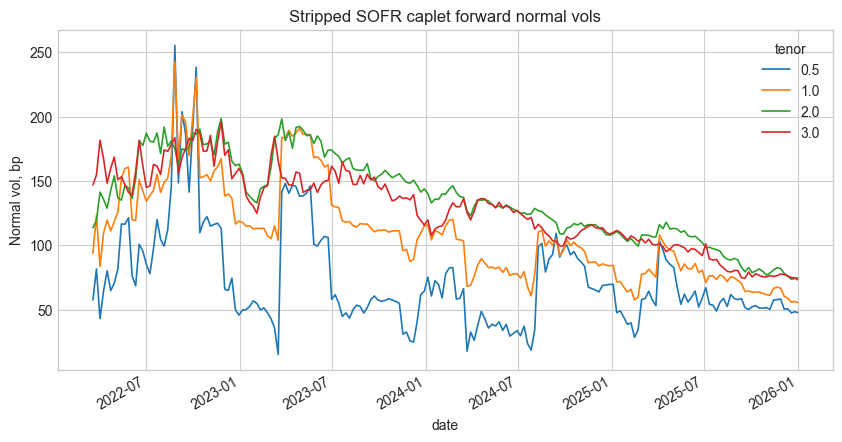

In [4]:

tenors = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
black_panel, normal_panel = build_forward_vol_panel(
    data,
    tenors=tenors,
    max_tenor=max(tenors),
    interpolation="cubic",
)

panel_summary = (normal_panel * 10000).agg(["mean", "std", "min", "max"]).T
panel_summary.columns = ["mean_bp", "std_bp", "min_bp", "max_bp"]
display(panel_summary)

fig, ax = plt.subplots(figsize=(10, 5))
(normal_panel[[0.5, 1.0, 2.0, 3.0]] * 10000).plot(ax=ax, linewidth=1.2)
ax.set_title("Stripped SOFR caplet forward normal vols")
ax.set_ylabel("Normal vol, bp")
plt.show()


,explained_variance
PC1,0.4494
PC2,0.2622
PC3,0.1391


,PC1,PC2,PC3
tenor,,,
0.5000,0.4415,0.4906,0.2083
1.0000,0.4962,0.4431,0.1027
1.5000,0.4690,-0.0379,-0.3134
2.0000,0.4404,-0.4320,-0.1781
3.0000,0.3311,-0.4622,-0.2441
5.0000,0.1878,-0.4017,0.8698


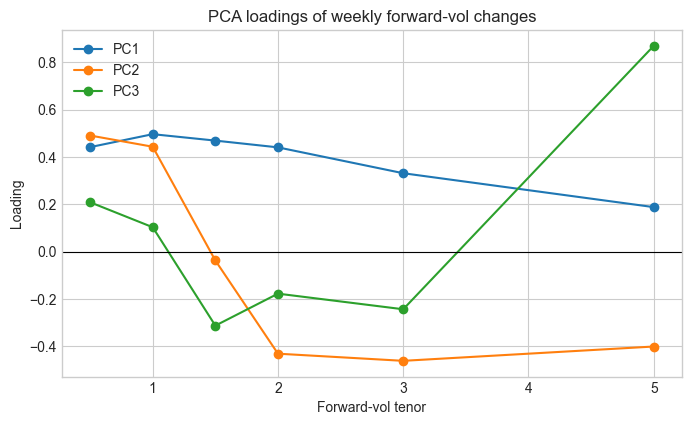

In [5]:

changes = normal_panel.dropna().diff().dropna() * 10000
scaled = StandardScaler().fit_transform(changes)
pca = PCA(n_components=3).fit(scaled)
loadings = pd.DataFrame(
    pca.components_.T,
    index=changes.columns,
    columns=["PC1", "PC2", "PC3"],
)
explained = pd.Series(pca.explained_variance_ratio_, index=loadings.columns, name="explained_variance")

display(explained.to_frame())
display(loadings)

fig, ax = plt.subplots(figsize=(8, 4.5))
loadings.plot(ax=ax, marker="o")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("PCA loadings of weekly forward-vol changes")
ax.set_xlabel("Forward-vol tenor")
ax.set_ylabel("Loading")
plt.show()



## 4. Expectations-hypothesis test

For each forward tenor `tau`, the test compares today's `tau` forward normal vol
to the future 0.5Y forward normal vol after `tau - 0.5` years.  The standard
errors use Newey-West/HAC lags matched to the forecast horizon because the
weekly observations are highly overlapping.


In [6]:

delta = 0.5
tau_list = [1.0, 1.5, 2.0, 3.0]

regression_table = predictive_regressions(normal_panel, delta=delta, tau_list=tau_list)
display(regression_table[[
    "horizon_years",
    "alpha_bp",
    "beta",
    "beta_hac_se",
    "t_beta_eq_1",
    "r2",
    "n_weekly",
    "effective_nonoverlap_n",
]].round(4))


,horizon_years,alpha_bp,beta,beta_hac_se,t_beta_eq_1,r2,n_weekly,effective_nonoverlap_n
tau,,,,,,,,
1.0000,0.5000,54.8205,0.1166,0.1398,-6.3203,0.0148,173,6
1.5000,1.0000,103.0160,-0.2598,0.1982,-6.3551,0.0741,147,2
2.0000,1.5000,22.9310,0.2249,0.0960,-8.0706,0.0572,121,1
3.0000,2.5000,35.0602,0.1766,0.0770,-10.6893,0.0263,69,1


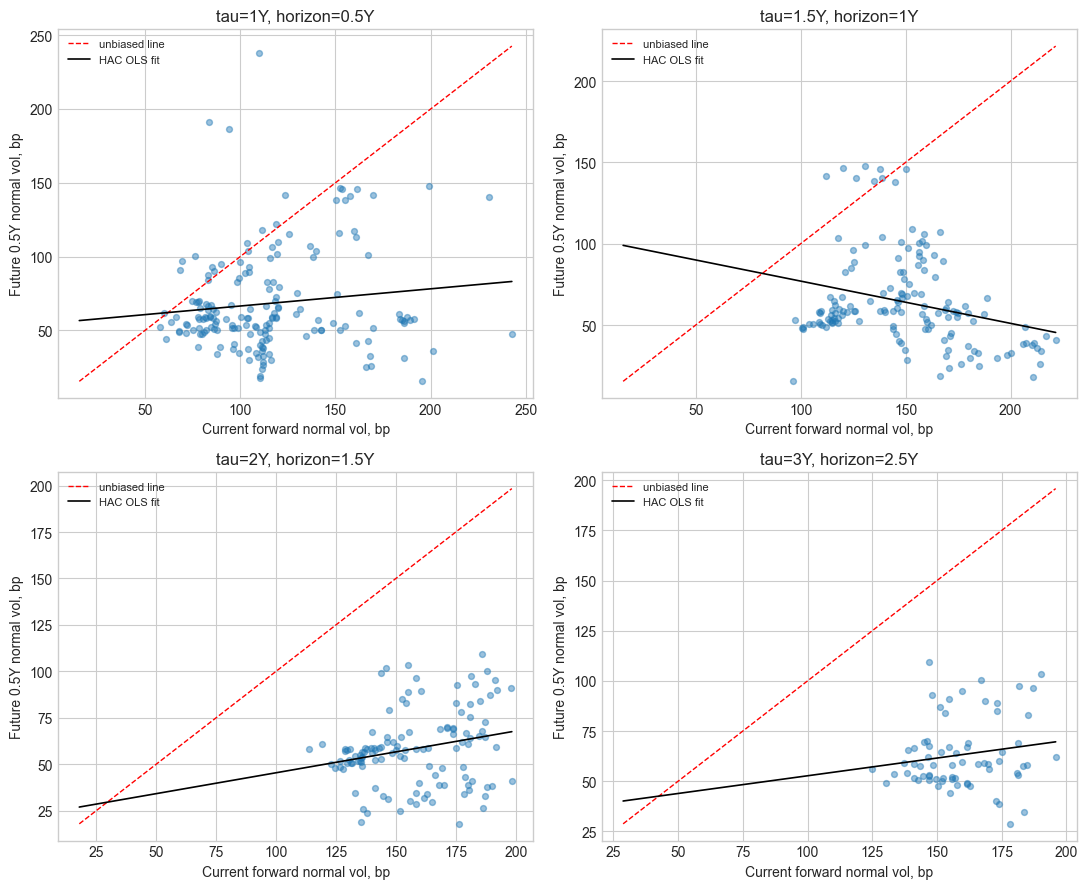

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
spot = normal_panel[delta]

for ax, tau in zip(axes.ravel(), tau_list):
    horizon_weeks = int(round((tau - delta) * 52))
    frame = pd.DataFrame(
        {
            "x": normal_panel[tau],
            "y": spot.shift(-horizon_weeks),
        }
    ).dropna() * 10000
    beta = regression_table.loc[tau, "beta"]
    alpha = regression_table.loc[tau, "alpha_bp"]
    ax.scatter(frame["x"], frame["y"], s=18, alpha=0.45)
    lo = min(frame["x"].min(), frame["y"].min())
    hi = max(frame["x"].max(), frame["y"].max())
    xgrid = np.linspace(lo, hi, 100)
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="unbiased line")
    ax.plot(xgrid, alpha + beta * xgrid, "k-", linewidth=1.2, label="HAC OLS fit")
    ax.set_title(f"tau={tau:g}Y, horizon={tau-delta:g}Y")
    ax.set_xlabel("Current forward normal vol, bp")
    ax.set_ylabel("Future 0.5Y normal vol, bp")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



## 5. Term premium, realized-vol benchmark, and regimes

The premium is measured in normal-vol bp.  The table separates the weekly count
from the effective non-overlapping count so long-horizon results are not
overstated.


,mean_bp,std_bp,frac_positive,weekly_ir,effective_nonoverlap_n,horizon_weeks
tau,,,,,,
1.0000,47.1073,46.9775,0.9075,1.0028,7,26
1.5000,84.9369,46.8751,0.9524,1.8120,3,52
2.0000,99.1522,25.4707,1.0000,3.8928,2,78
3.0000,96.0325,21.6898,1.0000,4.4275,1,130


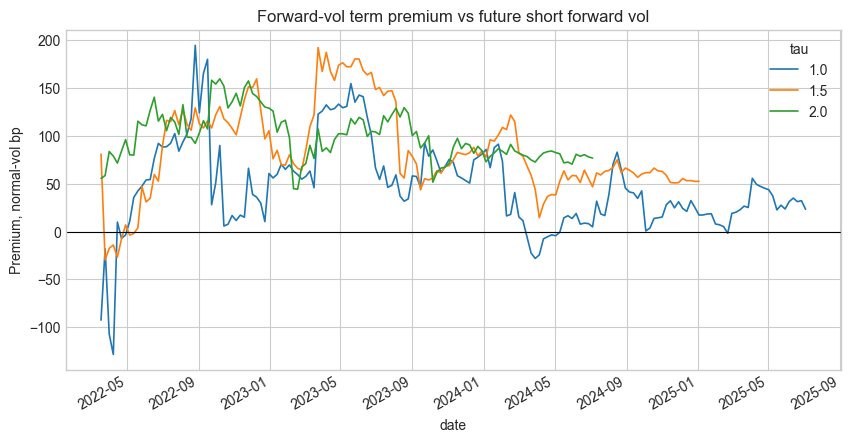

In [8]:

premium = term_premium_panel(normal_panel, delta=delta, tau_list=tau_list)
premium_stats = premium_summary(premium, delta=delta)
display(premium_stats.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
(premium[[1.0, 1.5, 2.0]] * 10000).plot(ax=ax, linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Forward-vol term premium vs future short forward vol")
ax.set_ylabel("Premium, normal-vol bp")
plt.show()


,mean,std,min,max,frac_positive
VRP_3M,32.1495,58.4805,-112.1208,137.9498,0.7222
VRP_6M,32.2257,57.7730,-110.2019,148.4817,0.6889


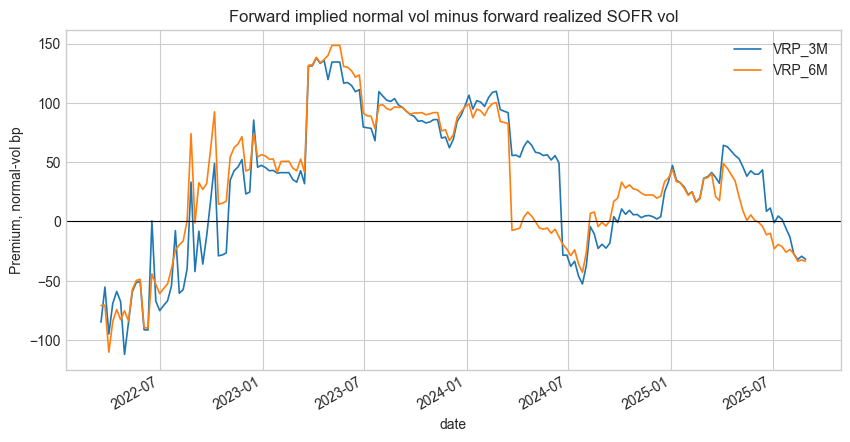

In [9]:

realized_3m = forward_realized_sofr_vol(data.sofr_daily, 63).resample("W-FRI").last()
realized_6m = forward_realized_sofr_vol(data.sofr_daily, 126).resample("W-FRI").last()
implied_1y = normal_panel[1.0]

vrp = pd.DataFrame(
    {
        "VRP_3M": implied_1y - realized_3m.reindex(implied_1y.index),
        "VRP_6M": implied_1y - realized_6m.reindex(implied_1y.index),
    }
).dropna()

vrp_stats = (vrp * 10000).agg(["mean", "std", "min", "max"]).T
vrp_stats["frac_positive"] = (vrp > 0).mean()
display(vrp_stats)

fig, ax = plt.subplots(figsize=(10, 5))
(vrp * 10000).plot(ax=ax, linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Forward implied normal vol minus forward realized SOFR vol")
ax.set_ylabel("Premium, normal-vol bp")
plt.show()


In [10]:

regime_rows = []
for label, frame in {
    "term_premium_1Y": premium[[1.0]].rename(columns={1.0: "value"}),
    "vrp_3M": vrp[["VRP_3M"]].rename(columns={"VRP_3M": "value"}),
}.items():
    tmp = frame.dropna().copy()
    tmp["regime"] = tmp.index.map(policy_regime)
    tmp = tmp[tmp["regime"] != "Other"]
    for regime_name, sub in tmp.groupby("regime"):
        s = sub["value"]
        regime_rows.append(
            {
                "measure": label,
                "regime": regime_name,
                "mean_bp": s.mean() * 10000,
                "std_bp": s.std() * 10000,
                "frac_positive": (s > 0).mean(),
                "n": len(s),
            }
        )

regime_table = pd.DataFrame(regime_rows).set_index(["measure", "regime"])
display(regime_table.round(3))


mean_bp  std_bp  frac_positive   n
measure         regime                                    
term_premium_1Y Easing  25.7900 13.3390         0.9770  44
                Hiking  66.1300 60.2800         0.9170  72
                Pause   39.5340 33.9710         0.8420  57
vrp_3M          Easing  16.9780 24.8690         0.8040  51
                Hiking  20.3070 73.6330         0.5970  72
                Pause   60.6820 47.8200         0.8070  57


## 6. Research conclusion

The curve contains a large positive forward-vol premium, but the evidence is not
strong enough to claim a mechanically harvestable strategy.  The highest
premium estimates sit at horizons where the effective number of independent
observations is tiny.  The disciplined recommendation is to treat the 1Y to
1.5Y sector as the credible research object and to frame longer maturities as
scenario/risk-premium diagnostics rather than a backtested alpha.


## Strategy extension: forecasted rates-vol carry

The first-pass analysis showed a persistent forward-vol premium, but a premium is not automatically a trade. This section converts the diagnostic into a stylized investability test: forecast future realized SOFR volatility using only lagged information, sell forward volatility when it is rich versus that forecast, buy it when it is cheap, and charge turnover costs. The P&L is a research proxy in normal-vol basis points, not a live caplet execution model.

In [11]:
from sofr_forward_vol import (
    VolCarryConfig,
    block_bootstrap_mean_ci,
    build_vol_carry_frame,
    expanding_ridge_forecast,
    regime_performance,
    strategy_performance,
    volatility_carry_backtest,
)

vol_strategy_config = VolCarryConfig(
    tenor=0.50,
    realized_window_days=63,
    min_train_weeks=52,
    threshold_bp=8.0,
    transaction_cost_bp=2.0,
    risk_target_bp=35.0,
    max_abs_position=1.0,
)
feature_cols = [
    "implied_vol",
    "lag_realized_vol",
    "vol_slope",
    "vol_momentum_13w",
    "vol_of_vol_13w",
]

strategy_frame = build_vol_carry_frame(
    normal_panel,
    data.sofr_daily,
    tenor=vol_strategy_config.tenor,
    realized_window_days=vol_strategy_config.realized_window_days,
)
strategy_predictions = expanding_ridge_forecast(
    strategy_frame,
    feature_cols,
    min_train=vol_strategy_config.min_train_weeks,
)
vol_strategy_bt = volatility_carry_backtest(
    strategy_frame,
    strategy_predictions,
    vol_strategy_config,
)

strategy_stats = pd.Series(strategy_performance(vol_strategy_bt), name="vol_carry_strategy")
bootstrap_ci = block_bootstrap_mean_ci(vol_strategy_bt["net_pnl_bp"], n_boot=1000)

display(strategy_frame[feature_cols + ["future_realized_vol"]].tail())
display(strategy_stats.to_frame())
display(regime_performance(vol_strategy_bt).round(4))
print(f"Block-bootstrap weekly mean P&L CI: {bootstrap_ci[0]:.2f} bp to {bootstrap_ci[1]:.2f} bp")

,implied_vol,lag_realized_vol,vol_slope,vol_momentum_13w,vol_of_vol_13w,future_realized_vol
date,,,,,,
2025-09-26,0.0050,0.0070,0.0026,-0.0009,0.0006,0.0108
2025-10-03,0.0052,0.0072,0.0023,-0.0015,0.0006,0.0114
2025-10-10,0.0053,0.0072,0.0024,-0.0001,0.0005,0.0119
2025-10-17,0.0052,0.0078,0.0023,-0.0002,0.0005,0.0121
2025-10-24,0.0051,0.0079,0.0022,0.0002,0.0005,0.0123


,vol_carry_strategy
total_pnl_bp,967.1418
ann_sharpe,1.8815
max_drawdown_bp,-434.0311
hit_rate,0.6774
active_periods,93.0000
turnover,12.8137


,total_pnl_bp,ann_sharpe,max_drawdown_bp,hit_rate,active_periods,turnover
regime,,,,,,
Easing,230.7695,0.9184,-434.0311,0.5556,54,9.8137
Hiking,0.0000,NaN,0.0000,NaN,0,0.0000
Pause,736.3723,3.0212,-263.9151,0.8462,39,3.0000


Block-bootstrap weekly mean P&L CI: -3.97 bp to 17.38 bp


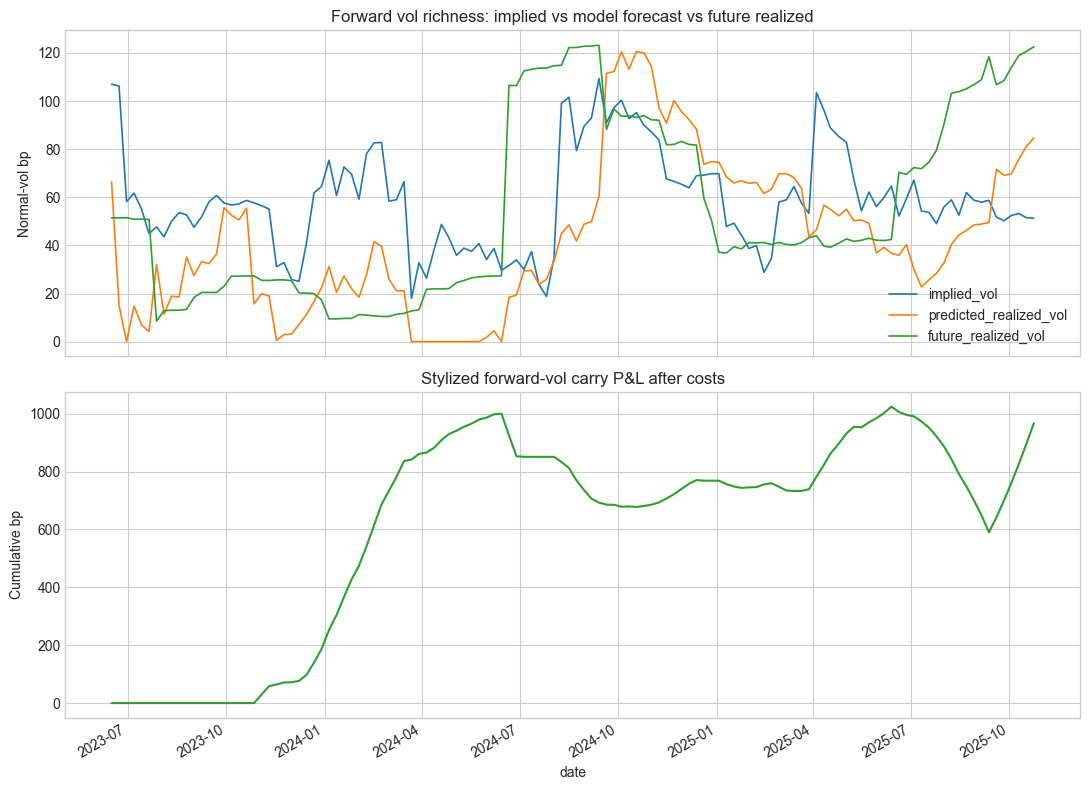

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
(vol_strategy_bt[["implied_vol", "predicted_realized_vol", "future_realized_vol"]] * 10000).plot(
    ax=axes[0],
    linewidth=1.2,
)
axes[0].set_title("Forward vol richness: implied vs model forecast vs future realized")
axes[0].set_ylabel("Normal-vol bp")
vol_strategy_bt["cum_net_pnl_bp"].plot(ax=axes[1], color="tab:green", linewidth=1.5)
axes[1].set_title("Stylized forward-vol carry P&L after costs")
axes[1].set_ylabel("Cumulative bp")
plt.tight_layout()
plt.show()

### Strategy interpretation

The strategy result is economically interesting because it uses only lagged information and survives a simple transaction-cost charge. The caveat is just as important: the realized-vol payoff is horizon-settled and overlapping, so the Sharpe is not a production statistic. The correct next step is caplet-level mark-to-market with bid/ask, margin, and actual cap/floor structures.

## Robustness and Anti-Overfit Checks

The strategy section is deliberately separated into forecast validation, tradability validation, and null simulation. The forward-realized-vol label overlaps across weekly observations, so ordinary shuffled cross-validation would leak path information. The checks below use purged and embargoed blocked k-fold validation for the realized-vol forecast, CPCV-style combinations of time blocks for pre-declared strategy configurations, block bootstrap intervals, and block-permutation nulls that break signal-label alignment while preserving local dependence. Distribution summaries report both mean and median outcomes because the simulated P&L paths are skewed and fat-tailed rather than Gaussian.

In [13]:
from sofr_forward_vol import (
    PurgedSplitConfig,
    block_bootstrap_path_summary,
    block_bootstrap_performance_ci,
    forecast_validation_table,
    strategy_block_permutation_null,
    strategy_cpcv_table,
    summarize_forecast_validation,
    summarize_strategy_cpcv,
)

sofr_split_config = PurgedSplitConfig(
    n_groups=6,
    n_test_groups=2,
    label_horizon=13,  # about 63 business days at weekly sampling
    embargo=2,
)

sofr_feature_sets = {
    "implied_only": ["implied_vol"],
    "implied_plus_realized": ["implied_vol", "lag_realized_vol"],
    "full_macro_curve_proxy": feature_cols,
}

forecast_cpcv = forecast_validation_table(
    strategy_frame,
    sofr_feature_sets,
    ridges=(1e-6, 1e-5, 1e-4),
    split_config=sofr_split_config,
    min_train=vol_strategy_config.min_train_weeks,
)
forecast_cpcv_summary = summarize_forecast_validation(forecast_cpcv)

display(forecast_cpcv_summary.round(4))


folds  mean_test_n  mean_rmse_bp  mean_mae_bp  \
feature_set            ridge                                                   
full_macro_curve_proxy 0.0001      6      29.3333       55.9372      49.2883   
                       0.0000      6      29.3333       55.9373      49.2884   
                       0.0000      6      29.3333       55.9373      49.2884   
implied_plus_realized  0.0001      6      31.5000       58.2839      54.1907   
                       0.0000      6      31.5000       58.2839      54.1907   
                       0.0000      6      31.5000       58.2839      54.1907   
implied_only           0.0001      6      31.5000       61.1231      55.9310   
                       0.0000      6      31.5000       61.1231      55.9310   
                       0.0000      6      31.5000       61.1231      55.9310   

                               mean_bias_bp  mean_corr  
feature_set            ridge                            
full_macro_curve_proxy 0.0001      -19.8876     0.1240  
                       0.0000      -19.8877     0.1240  
                       0.0000      -19.8878     0.1240  
implied_plus_realized  0.0001       -0.2539     0.2040  
                       0.0000       -0.2539     0.2040  
                       0.0000       -0.2539     0.2040  
implied_only           0.0001       -2.0491     0.1123  
                       0.0000       -2.0491     0.1123  
                       0.0000       -2.0491     0.1123

In [14]:
sofr_strategy_configs = [
    VolCarryConfig(threshold_bp=threshold, risk_target_bp=risk_target, transaction_cost_bp=cost, min_train_weeks=52)
    for threshold in (5.0, 8.0, 12.0)
    for risk_target in (25.0, 35.0)
    for cost in (2.0, 4.0)
]

strategy_cpcv = strategy_cpcv_table(
    strategy_frame,
    feature_cols,
    sofr_strategy_configs,
    ridges=(1e-5, 1e-4),
    split_config=sofr_split_config,
)
strategy_cpcv_summary = summarize_strategy_cpcv(strategy_cpcv)

display(strategy_cpcv_summary.head(12).round(4))


folds  \
config_id ridge  threshold_bp min_train_weeks risk_target_bp          
10        0.0001 12.0000      52              35.0000            15   
          0.0000 12.0000      52              35.0000            15   
2         0.0001 5.0000       52              35.0000            15   
          0.0000 5.0000       52              35.0000            15   
8         0.0001 12.0000      52              25.0000            15   
          0.0000 12.0000      52              25.0000            15   
0         0.0001 5.0000       52              25.0000            15   
          0.0000 5.0000       52              25.0000            15   
6         0.0001 8.0000       52              35.0000            15   
          0.0000 8.0000       52              35.0000            15   
4         0.0001 8.0000       52              25.0000            15   
          0.0000 8.0000       52              25.0000            15   

                                                              mean_test_n  \
config_id ridge  threshold_bp min_train_weeks risk_target_bp                
10        0.0001 12.0000      52              35.0000             58.6667   
          0.0000 12.0000      52              35.0000             58.6667   
2         0.0001 5.0000       52              35.0000             58.6667   
          0.0000 5.0000       52              35.0000             58.6667   
8         0.0001 12.0000      52              25.0000             58.6667   
          0.0000 12.0000      52              25.0000             58.6667   
0         0.0001 5.0000       52              25.0000             58.6667   
          0.0000 5.0000       52              25.0000             58.6667   
6         0.0001 8.0000       52              35.0000             58.6667   
          0.0000 8.0000       52              35.0000             58.6667   
4         0.0001 8.0000       52              25.0000             58.6667   
          0.0000 8.0000       52              25.0000             58.6667   

                                                              mean_total_pnl_bp  \
config_id ridge  threshold_bp min_train_weeks risk_target_bp                      
10        0.0001 12.0000      52              35.0000                  368.9102   
          0.0000 12.0000      52              35.0000                  368.9088   
2         0.0001 5.0000       52              35.0000                  372.3677   
          0.0000 5.0000       52              35.0000                  372.3662   
8         0.0001 12.0000      52              25.0000                  286.9796   
          0.0000 12.0000      52              25.0000                  286.9783   
0         0.0001 5.0000       52              25.0000                  287.8630   
          0.0000 5.0000       52              25.0000                  287.8616   
6         0.0001 8.0000       52              35.0000                  367.2586   
          0.0000 8.0000       52              35.0000                  367.2571   
4         0.0001 8.0000       52              25.0000                  283.0702   
          0.0000 8.0000       52              25.0000                  283.0688   

                                                              median_total_pnl_bp  \
config_id ridge  threshold_bp min_train_weeks risk_target_bp                        
10        0.0001 12.0000      52              35.0000                    374.0085   
          0.0000 12.0000      52              35.0000                    374.0084   
2         0.0001 5.0000       52              35.0000                    413.3984   
          0.0000 5.0000       52              35.0000                    413.3979   
8         0.0001 12.0000      52              25.0000                    267.1489   
          0.0000 12.0000      52              25.0000                    267.1489   
0         0.0001 5.0000       52              25.0000                    295.2846   
          0.0000 5.0000       52              25.0000       

In [15]:
sofr_null = strategy_block_permutation_null(
    strategy_frame,
    strategy_predictions,
    vol_strategy_config,
    block_size=8,
    n_sims=1000,
    seed=17,
)
sofr_bootstrap_perf_ci = block_bootstrap_performance_ci(
    vol_strategy_bt["net_pnl_bp"],
    block_size=8,
    n_boot=1000,
    seed=17,
)
sofr_bootstrap_path = block_bootstrap_path_summary(
    vol_strategy_bt["net_pnl_bp"],
    block_size=8,
    n_boot=1000,
    seed=17,
)

sofr_null_summary = pd.Series(
    {
        "observed_total_pnl_bp": sofr_null["observed_total_pnl_bp"].iloc[0],
        "observed_ann_sharpe": sofr_null["observed_ann_sharpe"].iloc[0],
        "block_permutation_pvalue_total": sofr_null["pvalue_total_pnl"].iloc[0],
        "block_permutation_pvalue_sharpe": sofr_null["pvalue_ann_sharpe"].iloc[0],
        "null_total_pnl_mean": sofr_null["total_pnl_bp"].mean(),
        "null_total_pnl_median": sofr_null["total_pnl_bp"].median(),
        "null_total_pnl_5pct": sofr_null["total_pnl_bp"].quantile(0.05),
        "null_total_pnl_95pct": sofr_null["total_pnl_bp"].quantile(0.95),
        "null_sharpe_mean": sofr_null["ann_sharpe"].mean(),
        "null_sharpe_median": sofr_null["ann_sharpe"].median(),
        "bootstrap_path_final_mean": sofr_bootstrap_path["mean_path"].iloc[-1],
        "bootstrap_path_final_median": sofr_bootstrap_path["median_path"].iloc[-1],
        **sofr_bootstrap_perf_ci,
    },
    name="sofr_robustness_nulls",
)

display(sofr_null_summary.to_frame())


,sofr_robustness_nulls
observed_total_pnl_bp,967.1418
observed_ann_sharpe,1.8815
block_permutation_pvalue_total,0.0790
block_permutation_pvalue_sharpe,0.0620
null_total_pnl_mean,-49.3254
null_total_pnl_median,-95.2083
null_total_pnl_5pct,"-1,130.9991"
null_total_pnl_95pct,"1,160.2556"
null_sharpe_mean,-0.0760
null_sharpe_median,-0.1590


In [16]:
sofr_sensitivity_rows = []
for realized_window in (42, 63, 84):
    sens_frame = build_vol_carry_frame(
        normal_panel,
        data.sofr_daily,
        tenor=vol_strategy_config.tenor,
        realized_window_days=realized_window,
    )
    sens_preds = expanding_ridge_forecast(
        sens_frame,
        feature_cols,
        min_train=vol_strategy_config.min_train_weeks,
    )
    for threshold in (5.0, 8.0, 12.0):
        for cost in (1.0, 2.0, 4.0):
            sens_cfg = VolCarryConfig(
                tenor=vol_strategy_config.tenor,
                realized_window_days=realized_window,
                min_train_weeks=52,
                threshold_bp=threshold,
                transaction_cost_bp=cost,
                risk_target_bp=vol_strategy_config.risk_target_bp,
                max_abs_position=vol_strategy_config.max_abs_position,
            )
            sens_bt = volatility_carry_backtest(sens_frame, sens_preds, sens_cfg)
            sofr_sensitivity_rows.append(
                {
                    "realized_window_days": realized_window,
                    "threshold_bp": threshold,
                    "transaction_cost_bp": cost,
                    **strategy_performance(sens_bt),
                }
            )

sofr_sensitivity = pd.DataFrame(sofr_sensitivity_rows)
display(
    sofr_sensitivity.pivot_table(
        index=["realized_window_days", "threshold_bp"],
        columns="transaction_cost_bp",
        values="ann_sharpe",
    ).round(3)
)


transaction_cost_bp                1.0000  2.0000  4.0000
realized_window_days threshold_bp                        
42                   5.0000        2.2510  2.2200  2.1590
                     8.0000        2.1720  2.1410  2.0770
                     12.0000       2.0940  2.0570  1.9840
63                   5.0000        1.7490  1.7110  1.6360
                     8.0000        1.9060  1.8820  1.8320
                     12.0000       2.5280  2.4940  2.4260
84                   5.0000        0.4880  0.4480  0.3700
                     8.0000        0.7950  0.7600  0.6880
                     12.0000       1.2940  1.2580  1.1850

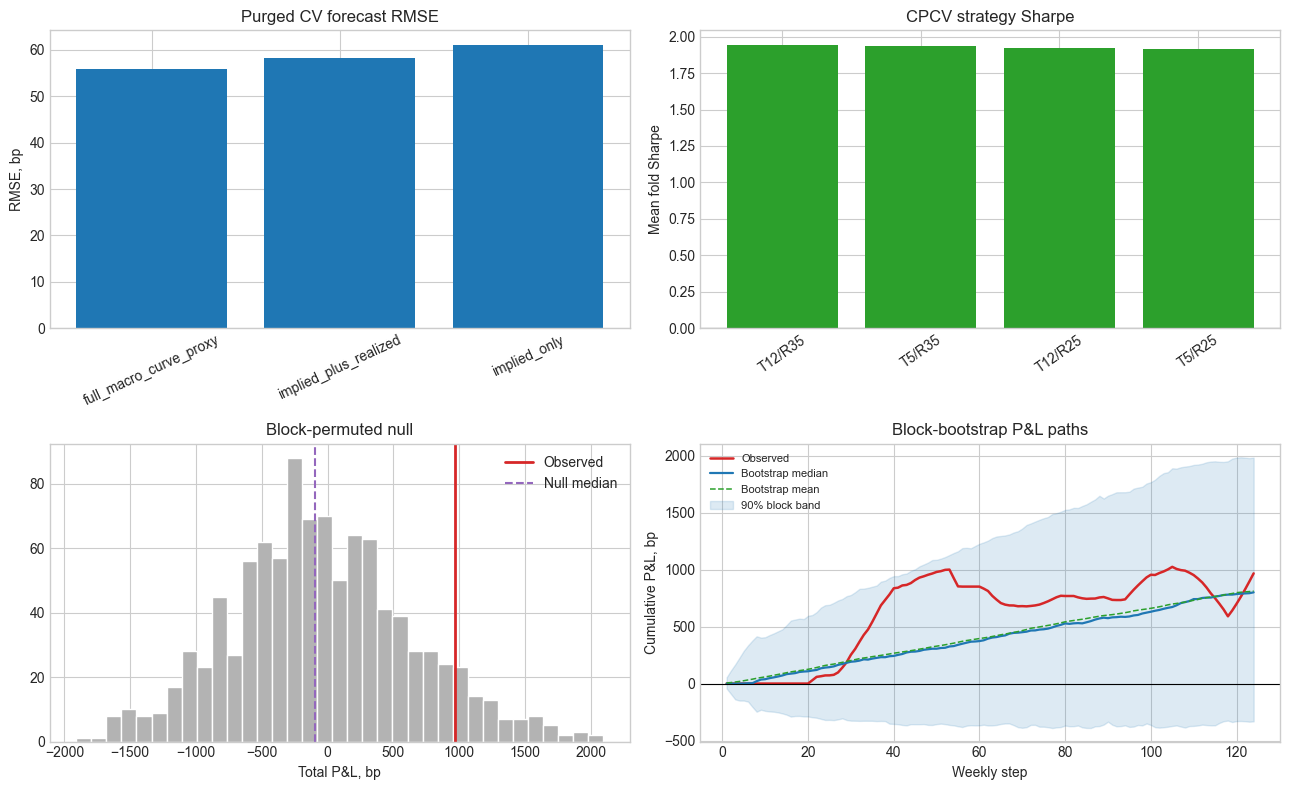

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

plot_cv = forecast_cpcv_summary.reset_index()
plot_cv = plot_cv[plot_cv["ridge"].eq(1e-5)]
axes[0].bar(plot_cv["feature_set"], plot_cv["mean_rmse_bp"], color="tab:blue")
axes[0].set_title("CPCV forecast RMSE")
axes[0].set_ylabel("RMSE, bp")
axes[0].tick_params(axis="x", rotation=25)

plot_cpcv = strategy_cpcv_summary.reset_index().head(8)
labels = [f"T{row.threshold_bp:.0f}/R{row.risk_target_bp:.0f}" for _, row in plot_cpcv.iterrows()]
axes[1].bar(labels, plot_cpcv["mean_ann_sharpe"], color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("CPCV strategy Sharpe")
axes[1].set_ylabel("Mean fold Sharpe")
axes[1].tick_params(axis="x", rotation=35)

axes[2].hist(sofr_null["total_pnl_bp"], bins=35, color="0.7", edgecolor="white")
axes[2].axvline(sofr_null_summary["observed_total_pnl_bp"], color="tab:red", linewidth=2, label="Observed")
axes[2].axvline(sofr_null_summary["null_total_pnl_median"], color="tab:purple", linestyle="--", linewidth=1.5, label="Null median")
axes[2].set_title("Block-permuted null")
axes[2].set_xlabel("Total P&L, bp")
axes[2].legend()

axes[3].plot(sofr_bootstrap_path.index, sofr_bootstrap_path["observed_path"], color="tab:red", linewidth=1.8, label="Observed")
axes[3].plot(sofr_bootstrap_path.index, sofr_bootstrap_path["median_path"], color="tab:blue", linewidth=1.6, label="Bootstrap median")
axes[3].plot(sofr_bootstrap_path.index, sofr_bootstrap_path["mean_path"], color="tab:green", linewidth=1.1, linestyle="--", label="Bootstrap mean")
axes[3].fill_between(
    sofr_bootstrap_path.index,
    sofr_bootstrap_path["lower_path"],
    sofr_bootstrap_path["upper_path"],
    color="tab:blue",
    alpha=0.15,
    label="90% block band",
)
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_title("Block-bootstrap P&L paths")
axes[3].set_xlabel("Weekly step")
axes[3].set_ylabel("Cumulative P&L, bp")
axes[3].legend(fontsize=8)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "paper" / "figures" / "sofr_robustness_summary.pdf", bbox_inches="tight")
plt.show()
